# Conway's Game of Life
### A spatial cellular automaton with dissmodel

Conway's Game of Life is a classic example of how simple local rules
produce complex emergent behavior. Each cell is either **alive** (1)
or **dead** (0), and its next state depends only on its 8 neighbors.

## Rules

| Current state | Live neighbors | Next state |
|:---:|:---:|:---:|
| Alive | < 2 | Dies (underpopulation) |
| Alive | 2 or 3 | Survives |
| Alive | > 3 | Dies (overpopulation) |
| Dead | exactly 3 | Born |

> All other cells remain dead.

## Imports

In [1]:
from matplotlib.colors import ListedColormap

from dissmodel.core import Environment
from dissmodel.geo import vector_grid
from dissmodel.models.ca import GameOfLife
from dissmodel.models.ca.game_of_life import PATTERNS
from dissmodel.visualization.map import Map

## ⚠️ Important: instantiation order

The `Environment` must always be created **before** any model (`GameOfLife`, `Map`, `Chart`).
Models connect to the active environment automatically when instantiated —
if no environment exists yet, the connection fails.

```
Environment  →  GameOfLife  →  Map
     ↑               ↑          ↑
  first          second        third
```

In [2]:
# 1. Environment must be created first
env = Environment(start_time=0, end_time=15)

## Setting up the grid

We create a 20x20 abstract grid where every cell begins dead (`state=0`).

In [3]:
gdf = vector_grid(dimension=(20, 20), resolution=1, attrs={"state": 0})
gdf.head()

,geometry,state
id,,
0-0,"POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))",0
1-0,"POLYGON ((1 1, 1 2, 0 2, 0 1, 1 1))",0
2-0,"POLYGON ((1 2, 1 3, 0 3, 0 2, 1 2))",0
3-0,"POLYGON ((1 3, 1 4, 0 4, 0 3, 1 3))",0
4-0,"POLYGON ((1 4, 1 5, 0 5, 0 4, 1 4))",0


## Available patterns

dissmodel ships with classic Game of Life patterns grouped by category:

- **Oscillators** — return to initial state after N steps (`blinker`, `toad`, `beacon`, `pulsar`)
- **Spaceships** — move across the grid (`glider`, `lwss`)
- **Still lifes** — never change (`block`, `beehive`, `loaf`)

In [4]:
for name, pattern in PATTERNS.items():
    print(f"{name:10} — {len(pattern)}x{len(pattern[0])}")

blinker    — 1x3
toad       — 2x4
beacon     — 4x4
pulsar     — 13x13
glider     — 3x3
lwss       — 4x5
block      — 2x2
beehive    — 3x4
loaf       — 4x4


## Initializing the model

Two initialization options are available:

- `initialize()` — random 60/40 live/dead split
- `initialize_patterns([...])` — place classic patterns at random positions

In [5]:
# 2. Model connects to the active environment automatically
gol = GameOfLife(gdf=gdf)

# Choose one:
gol.initialize_patterns(["glider", "blinker", "toad", "beacon"])
# gol.initialize()  # ← uncomment for random initialization

## Visualization

The `Map` model redraws the grid at every simulation step.
It connects to the same environment and runs in sync with `GameOfLife`.

In [6]:
# 3. Map also connects to the active environment automatically
cmap = ListedColormap(["white", "black"])
Map(
    gdf=gdf,
    plot_params={"column": "state", "cmap": cmap, "ec": "gray"},
)

Map (map.0)

## Running the simulation

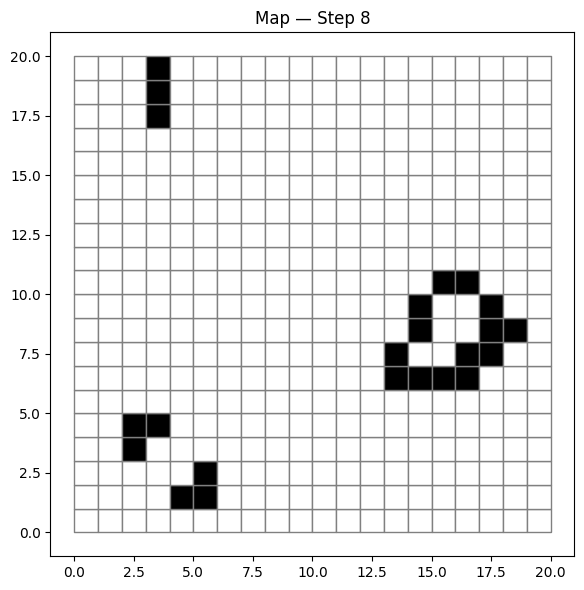

In [ ]:
env.run()

## Try it yourself

Go back and experiment:

- Change `end_time` in `Environment` to run more steps
- Change `dimension` in `vector_grid` for a larger grid
- Try `initialize_patterns(["pulsar"])` with a grid >= 15x15
- Try `initialize()` for a fully random start